## Final Project: Are Used Cars Worth It?

The used car market is very dynamic. Prices of used cars are influenced by a variety of endless factors, some of which include car age, mileage, condition of the car, accident history, brand reputation, etc. Because of the multitude of factors, it can be hard to determine if a used car's listed price actually reflects the quality of the car. Because the car is not brand new anymore, it is hard to compare the used car's price to what the price would be if it were brand new. Sellers of used cars can price vehicles based on their subjective expectations, market trends, or trying even an attempt to sell the car for more money than the car is actually worth. This can lead to similar cars being priced at different price points, causing confusion between buyers and hesitation when purchasing a used car. So, this raised a question for us that we explored in this project: Can we find a way to determine if a car is overpriced or underpriced based on the actual quality of the car? 

To answer this question, we analyzed a dataset of used cars that contained mvarious useful factors such as make, model, car age, fuel efficiency, mileage, horsepower, condition (used or damaged), body type, and price. We wanted to find out how these factors contributed to a car's expected price and if these prices were actually justified based on the condition of the car. We want to find vehicles that deviate from expected pricing by comparing predicted values based on our factors of interest to actual listing prices. Thus, we can find potential "steals" for cars as well as identify overpriced cars to avoid purchasing, giving insight into how well the car market represents the underlying car quality and condition. 

### Exploratory Data Analysis

In [107]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from matplotlib.patches import Ellipse

In [108]:
# Import dataset
car_original = pd.read_csv('car_price_dataset.csv')
car = car_original.sample(n=1000, random_state=42)


In [109]:
# View dataset
car.head()

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,...,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km),PricePerKm,Price($)
33553,Toyota,RAV4,2007,18,Used,263330,2.5,Gasoline,206,372,...,Black,Leather,"Cruise Control, Bluetooth, Heated Seats, Touch...",Paris,No,Valid,Incomplete,12.15,0.01,3653
9427,Volkswagen,Golf,2017,8,Used,115081,1.9,Gasoline,172,284,...,Silver,Cloth,Navigation,Berlin,No,Valid,Incomplete,9.69,0.09,10251
199,Honda,Civic,2024,1,Used,15292,1.8,Gasoline,180,254,...,White,Leather,"Bluetooth, Cruise Control, Sunroof",Tokyo,No,Expired,Incomplete,7.91,1.29,19674
12447,Tesla,Model 3,2005,20,Used,287467,0.0,Electric,382,623,...,Blue,Leather,"Rear Camera, Touchscreen, Bluetooth, Heated Seats",Delhi,No,Expired,Incomplete,0.00,0.01,3918
39489,Mercedes-Benz,C-Class,2022,3,Damaged,44484,2.7,Hybrid,329,351,...,Silver,Leather,"Navigation, Heated Seats",Paris,No,Valid,Incomplete,11.02,0.30,13260


#### Distribution of Price

We initially want to examing the distribution of price, since we will use it as our target variable for later analysis. The KDE plot below shows that most cars in this dataset are below around $40,000.

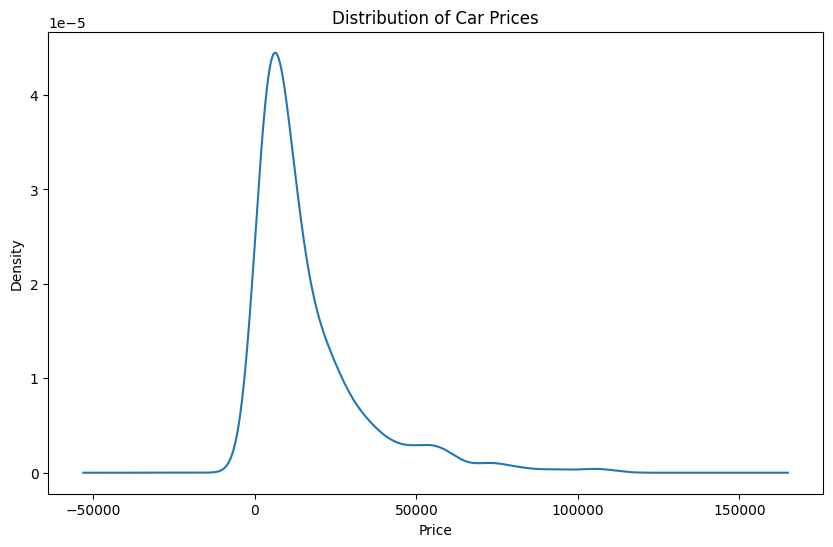

In [110]:
# kde plot of price
plt.figure(figsize=(10, 6))
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Density')
car['Price($)'].plot(kind='kde')
plt.show()

#### Price and Mileage
One of the most common factors both sellers and buyers factor into buying a used car is how much mileage is on the car. More mileage can increase risk of the car's performance as well as how much longer the car can be driven.

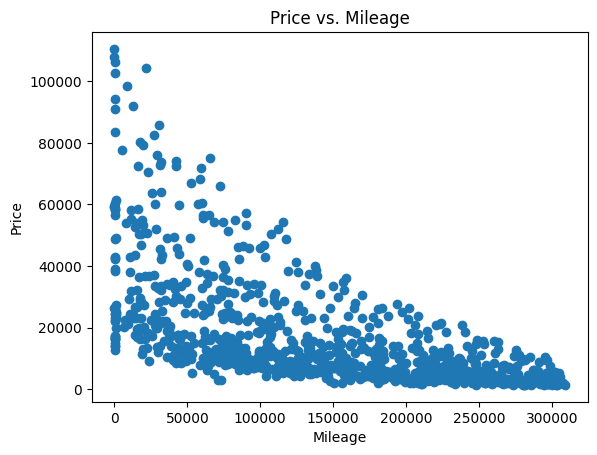

In [111]:
# Visualize mileage and price relationship
plt.figure()
plt.scatter(car['Mileage(km)'], car['Price($)'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Price vs. Mileage')
plt.show()

#### Price and Age
The next biggest factor that matters to both parties is the age of the car. We want to see this distribution in our dataset.

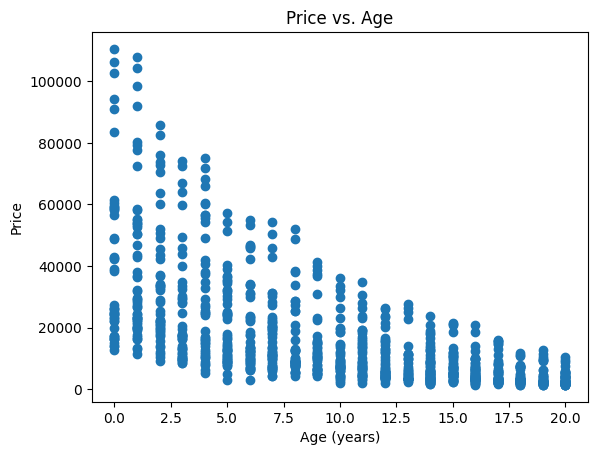

In [112]:
# Visualize price an age relationship
plt.figure()
plt.scatter(car['CarAge'], car['Price($)'])
plt.xlabel('Age (years)')
plt.ylabel('Price')
plt.title('Price vs. Age')
plt.show()

#### Price and Fuel Efficiency
One slightly less common factor is fuel efficiency. This factor, however, is just as important as it speaks to the performance on the car as well as the future investment into the car needed. Fuel efficiency essentially shows how well the car handles gas. With lower fuel efficiency, the car could still be a big financial investment as filling up the tank would add up if the fuel efficiency was low.

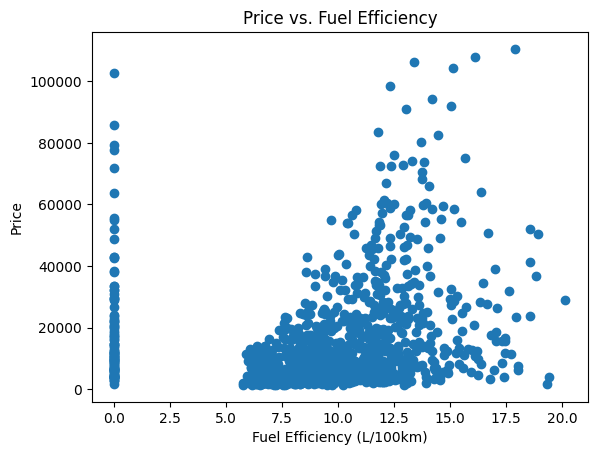

In [113]:
# View fuel efficiency and price relationship
plt.figure()
plt.scatter(car['FuelEfficiency(L/100km)'], car['Price($)'])
plt.xlabel('Fuel Efficiency (L/100km)')
plt.ylabel('Price')
plt.title('Price vs. Fuel Efficiency')
plt.show()

There are outliers in this distribution of fuel efficiency. These are cars with 0.0 fuel efficiency, which does not help our goal of fidning potential cars to buy. Even if these cars were purchased, the quality of the car diminishes as the car cannot even run or be driven. We will drop these rows as they are inefficient cars.

In [114]:
car = car[car['FuelEfficiency(L/100km)'] != 0]

### Methods
We will be using kMeans clustering without any log transformations. 

First, we will clean our dataset and identify the variabe we want to investigate, which is price.

In [115]:
# Drop unnecessary columns and set target variable 
#keep Mileage(km), CarAge, Condition, AccidentHistory, FuelEfficiency(L/100km), Horsepower, BodyType, 

car_no_log = car.drop(columns=[
    'Brand', 'Model', 'Year', 'EngineSize(L)', 'Torque', 'Transmission',
    'DriveType', 'Doors', 'Seats', 'Color', 'Interior', 'Options', 'City',
    'Insurance', 'RegistrationStatus', 'FuelType', 'PricePerKm'
])

# Drop rows that are new cars (Condition = 'New')
car_no_log = car_no_log[car_no_log['Condition'] != 'New']
car_no_log = car_no_log[car_no_log['Mileage(km)'] != 0] # remove the outlier with 0 mileage but is still classified as used...

target = car_no_log['Price($)'] # set target variable after dropping rows

car_no_log = car_no_log.drop(columns=['Price($)']) # drop target variable from features
print(car_no_log.shape)
print(target.shape)

(858, 7)
(858,)


In [116]:
# One hot encode categorical variables
car_no_log = pd.get_dummies(car_no_log, columns=['Condition', 'BodyType', 'AccidentHistory'], drop_first=True, dtype=int)

In [117]:
#scale numeric data
scaler = StandardScaler()
scaled_no_log = scaler.fit_transform(car_no_log)

In [118]:
# kMeans with guess for k=3
kmeans = KMeans(n_clusters=3, random_state=42)
# Fit model to training data
kmeans.fit(scaled_no_log)
# Predictions
clusters = kmeans.predict(scaled_no_log)
# Show clusters
car_no_log["Cluster"] = clusters
print(car_no_log["Cluster"])

33553    0
9427     1
199      0
39489    0
42724    0
        ..
33981    0
31260    0
12292    0
42286    1
13664    0
Name: Cluster, Length: 858, dtype: int32


In [119]:
# Group Clusters by mean
car_no_log.groupby("Cluster").mean()

,CarAge,Mileage(km),Horsepower,FuelEfficiency(L/100km),Condition_Used,BodyType_Coupe,BodyType_Hatchback,BodyType_Pickup,BodyType_SUV,BodyType_Sedan,AccidentHistory_Yes
Cluster,,,,,,,,,,,
0,10.343606,155157.300462,302.029276,11.321525,0.896764,0.121726,0.0,0.0,0.283513,0.557781,0.209553
1,10.533679,158147.580311,123.601036,7.398446,0.906736,0.000000,1.0,0.0,0.000000,0.000000,0.248705
2,11.750000,175382.000000,384.812500,16.360000,0.812500,0.000000,0.0,1.0,0.000000,0.000000,0.250000


In [120]:
#centers of clusters
print(kmeans.cluster_centers_)

[[-1.19484391e-02 -1.21132054e-02  3.07653562e-01  2.85792607e-01
  -2.21380930e-03  1.02552536e-01 -5.38725871e-01 -1.37849103e-01
   1.68259871e-01  2.75115486e-01 -2.31141019e-02]
 [ 2.09743899e-02  2.23907419e-02 -1.11475991e+00 -1.13611935e+00
   3.06532631e-02 -3.18452613e-01  1.85623163e+00 -1.37849103e-01
  -5.22491179e-01 -8.54305981e-01  7.15356364e-02]
 [ 2.31654982e-01  2.21253571e-01  9.67593791e-01  2.11197702e+00
  -2.79957347e-01 -3.18452613e-01 -5.38725871e-01  7.25430906e+00
  -5.22491179e-01 -8.54305981e-01  7.46671454e-02]]


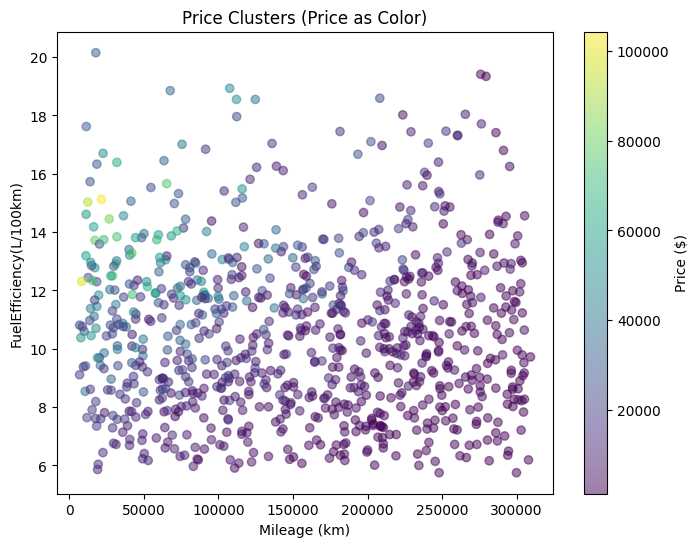

In [121]:
# Visualization of top variables
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    car_no_log["Mileage(km)"],
    car_no_log["FuelEfficiency(L/100km)"],
    c=target,
    alpha = 0.5
)
plt.colorbar(scatter, label="Price ($)")
plt.xlabel("Mileage (km)")
plt.ylabel("FuelEfficiency(L/100km)")
plt.title("Price Clusters (Price as Color)")
plt.show()


#### These clusters are not clear. We will repeat the process but take the log of the data before scaling it. This will help with dramatic skew in the data.

In [122]:
# Drop unnecessary columns and set target variable

#keep Mileage(km), CarAge, Condition, AccidentHistory, FuelEfficiency(L/100km), Horsepower, BodyType, 
car_df = car.drop(columns=[
    'Brand', 'Model', 'Year', 'EngineSize(L)', 'Torque', 'Transmission',
    'DriveType', 'Doors', 'Seats', 'Color', 'Interior', 'Options', 'City',
    'Insurance', 'RegistrationStatus', 'FuelType', 'PricePerKm'
])

# Drop rows that are new cars (Condition = New)
car_df = car_df[car_df['Condition'] != 'New']
car_df = car_df[car_df['Mileage(km)'] != 0] # remove the outlier with 0 mileage but is still classified as used...

target = car_df["Price($)"] #target variable

car_df = car_df.drop(columns=["Price($)"]) # Drop price column from features
car_df.shape

(858, 7)

In [123]:
count = (car_df["FuelEfficiency(L/100km)"] == 0).sum()
print(count)

0


In [124]:
# View the cleaned dataset
car_df.head()

,CarAge,Condition,Mileage(km),Horsepower,BodyType,AccidentHistory,FuelEfficiency(L/100km)
33553,18,Used,263330,206,SUV,No,12.15
9427,8,Used,115081,172,Hatchback,No,9.69
199,1,Used,15292,180,Sedan,No,7.91
39489,3,Damaged,44484,329,Sedan,No,11.02
42724,5,Damaged,80806,343,Sedan,No,12.64


We need to one-hot encode our categorical variables, so these can still be used in the clustering. We want to keep things like condition, accident history, and body type of the car as these factors would impact the price and quality of the car.

In [125]:
# One hot encode categorical variables
car_df = pd.get_dummies(car_df, columns=['Condition', 'BodyType', 'AccidentHistory'], drop_first=True, dtype=int)

We need to scale the numerical data to help the outliers from dominating the Euclidean distance calculation, and provde clearer clusters.

In [126]:
# scale numerical data with log to help with skew and make clearer clusters
car_df["Mileage(km)"] = np.log1p(car_df["Mileage(km)"])
car_df["FuelEfficiency(L/100km)"] = np.log1p(car_df["FuelEfficiency(L/100km)"])
car_df["Horsepower"] = np.log1p(car_df["Horsepower"])
car_df["CarAge"] = np.log1p(car_df["CarAge"])

In [127]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(car_df)


In [128]:
# kMeans with guess for k=3
kmeans = KMeans(n_clusters=3, random_state=42)
# Fit model to training data
kmeans.fit(scaled_data)
# Predictions
clusters = kmeans.predict(scaled_data)
# Show clusters
car_df["Cluster"] = clusters
print(car_df["Cluster"])

33553    0
9427     1
199      2
39489    2
42724    2
        ..
33981    2
31260    2
12292    0
42286    1
13664    2
Name: Cluster, Length: 858, dtype: int32


In [129]:
# Group Clusters by mean
car_df.groupby("Cluster").mean()

,CarAge,Mileage(km),Horsepower,FuelEfficiency(L/100km),Condition_Used,BodyType_Coupe,BodyType_Hatchback,BodyType_Pickup,BodyType_SUV,BodyType_Sedan,AccidentHistory_Yes
Cluster,,,,,,,,,,,
0,2.278009,11.730681,5.655178,2.573244,0.904943,0.30038,0.0,0.000000,0.69962,0.000000,0.212928
1,2.284936,11.756756,4.757184,2.122021,0.906736,0.00000,1.0,0.000000,0.00000,0.000000,0.248705
2,2.231342,11.686285,5.653694,2.456938,0.888060,0.00000,0.0,0.039801,0.00000,0.900498,0.208955


In [130]:
#centers of clusters
print(kmeans.cluster_centers_)

[[ 0.0308589   0.01837091  0.38829609  0.66047332  0.02474406  0.72045363
  -0.53872587 -0.1378491   1.18206179 -0.85430598 -0.01495593]
 [ 0.04138628  0.05044382 -1.33198919 -1.25001801  0.03065326 -0.31845261
   1.85623163 -0.1378491  -0.52249118 -0.85430598  0.07153564]
 [-0.04005831 -0.03623683  0.38545284  0.16803232 -0.03090489 -0.31845261
  -0.53872587  0.15636615 -0.52249118  0.9690635  -0.02455962]]


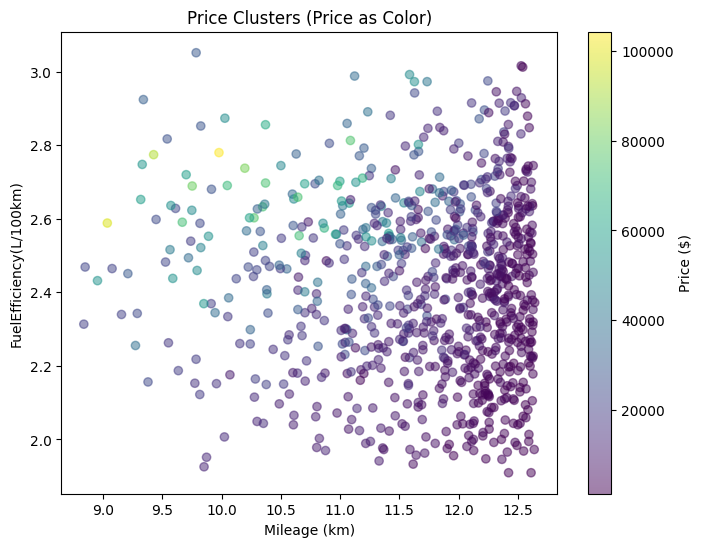

In [131]:
# Visualization of top variables
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    car_df["Mileage(km)"],
    car_df["FuelEfficiency(L/100km)"],
    c=target,
    alpha = 0.5
)
plt.colorbar(scatter, label="Price ($)")
plt.xlabel("Mileage (km)")
plt.ylabel("FuelEfficiency(L/100km)")
plt.title("Price Clusters (Price as Color)")
plt.show()


In [132]:
# Evaluate quality of clusters using silhouette score
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(scaled_data)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_data, labels))

print("Total Variance for k=2-10:", inertias)
print("Silhouette Scores for k=2-10:", sil_scores)
print("Model Score for k=10:", km.score(scaled_data))
# %%

Total Variance for k=2-10: [7466.833609394796, 6250.623326079, 5208.329104133959, 4260.347336075728, 3627.940491681723, 3518.7848653789993, 3124.320114817335, 2897.8684214146065, 2660.3756550122657]
Silhouette Scores for k=2-10: [0.252667048404374, 0.2864438168187064, 0.3492172328802562, 0.3730382192257103, 0.3600451769436929, 0.3542767567083559, 0.36403748267794855, 0.3244051933699187, 0.33521827591803116]
Model Score for k=10: -2660.375655012266


### Evaluation

We need to create an elbow plot to find the best k we should use.

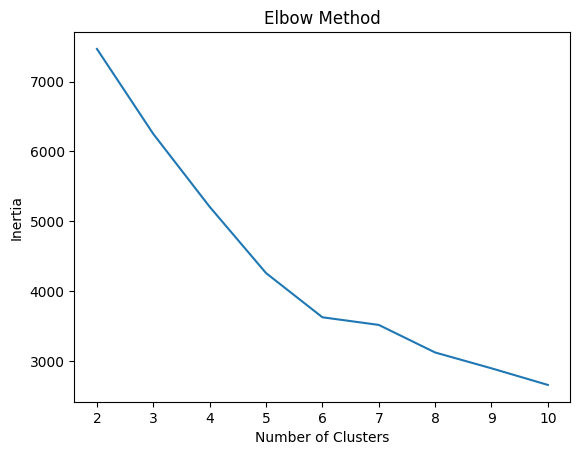

In [133]:
# Elbow plot to find ideal k (# of clusters)
plt.plot(k_range, inertias)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Silhouette scores can help us justify our chosen k.

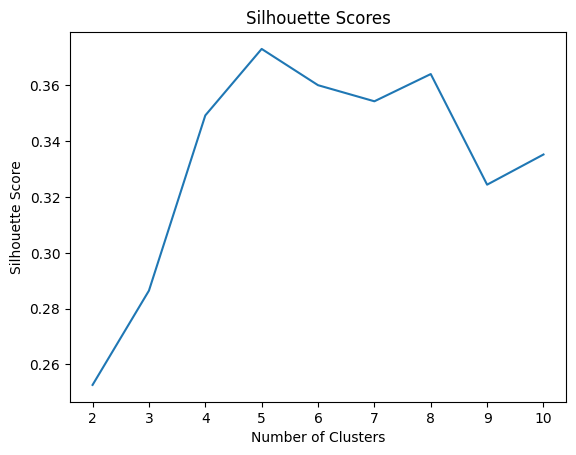

In [134]:
# Silhouette scores for k=2-10
plt.plot(k_range, sil_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

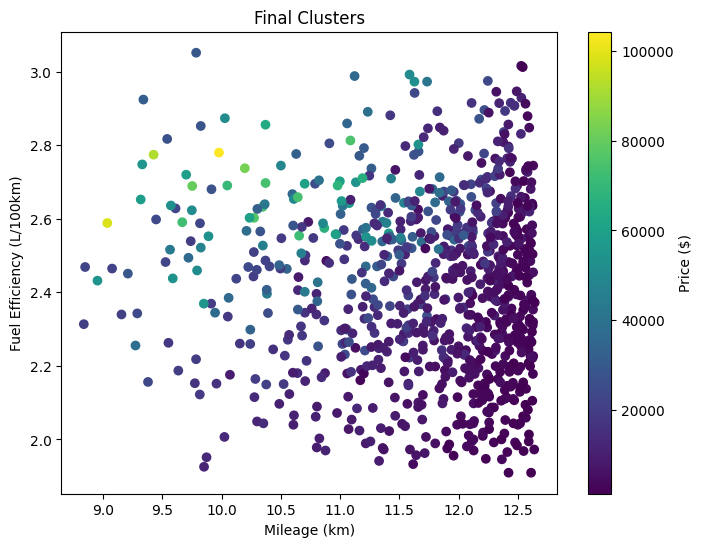

In [135]:
# Run final model with k=6
kmeans_final = KMeans(n_clusters=6, random_state=42)
car_df["Cluster_Final"] = kmeans_final.fit_predict(scaled_data)

plt.figure(figsize=(8,6))
final = plt.scatter(
    car_df["Mileage(km)"],
    car_df["FuelEfficiency(L/100km)"],
    c=target
)

plt.colorbar(final, label="Price ($)")
plt.xlabel("Mileage (km)")
plt.ylabel("Fuel Efficiency (L/100km)")
plt.title("Final Clusters")
plt.show()

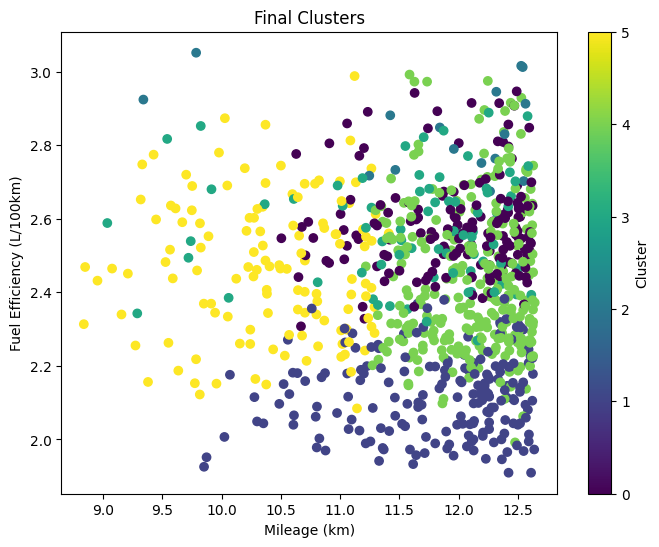

In [136]:
# labeling clusters

plt.figure(figsize=(8,6))
final = plt.scatter(
    car_df["Mileage(km)"],
    car_df["FuelEfficiency(L/100km)"],
    c=car_df["Cluster_Final"],
    cmap='viridis'
)

plt.colorbar(final, label="Cluster", ticks=range(6))
plt.xlabel("Mileage (km)")
plt.ylabel("Fuel Efficiency (L/100km)")
plt.title("Final Clusters")
plt.show()

In [137]:
# Evaluate final clusters
print("Final Inertia:", kmeans_final.inertia_)
print("Final Silhouette:", silhouette_score(scaled_data, car_df["Cluster_Final"]))
# %%

Final Inertia: 3627.940491681723
Final Silhouette: 0.3600451769436929


In [138]:
# convert numerical data back to original for summary interpretation
car_df["Mileage(km)"] = np.expm1(car_df["Mileage(km)"])
car_df["FuelEfficiency(L/100km)"] = np.expm1(car_df["FuelEfficiency(L/100km)"])
car_df["Horsepower"] = np.expm1(car_df["Horsepower"])
car_df["CarAge"] = np.expm1(car_df["CarAge"])

In [139]:
# Bring back make and model
car_df["Brand"] = car["Brand"]
car_df["Model"] = car["Model"]

In [140]:
# Use the model to find underpriced and overpriced cars based on quality
car_df["Price($)"] = target
car_df["Cluster"] = car_df["Cluster_Final"]
car_df["Difference"] = car_df["Price($)"] - car_df.groupby("Cluster")["Price($)"].transform("median")


In [148]:
# Underpriced cars
car_df.sort_values("Difference").head(10)


,CarAge,Mileage(km),Horsepower,FuelEfficiency(L/100km),Condition_Used,BodyType_Coupe,BodyType_Hatchback,BodyType_Pickup,BodyType_SUV,BodyType_Sedan,AccidentHistory_Yes,Cluster,Cluster_Final,Brand,Model,Price($),Difference
1118,4.0,60435.0,158.0,8.25,1,0,0,0,0,1,1,5,5,Honda,Civic,10138,-18700.5
46358,3.0,49074.0,330.0,9.98,0,0,0,0,0,1,0,5,5,BMW,3 Series,11807,-17031.5
18048,4.0,64136.0,331.0,9.53,0,0,0,0,0,1,0,5,5,Mercedes-Benz,C-Class,12109,-16729.5
13238,5.0,74477.0,216.0,9.91,1,0,0,0,0,1,0,5,5,Mazda,Mazda3,12578,-16260.5
20815,5.0,80059.0,203.0,9.59,1,0,0,0,0,1,0,5,5,Mazda,Mazda3,12759,-16079.5
20930,3.0,41964.0,222.0,10.09,1,0,0,0,0,1,1,5,5,Toyota,Camry,12787,-16051.5
3016,5.0,69054.0,177.0,7.04,1,0,0,0,0,1,0,5,5,Hyundai,Elantra,12894,-15944.5
39489,3.0,44484.0,329.0,11.02,0,0,0,0,0,1,0,5,5,Mercedes-Benz,C-Class,13260,-15578.5
20268,4.0,49040.0,169.0,9.38,1,0,0,0,0,1,0,5,5,Toyota,Corolla,14052,-14786.5
15384,3.0,38944.0,157.0,8.82,1,0,0,0,0,1,0,5,5,Hyundai,Elantra,14125,-14713.5


In [147]:
# Overpriced cars
car_df.sort_values("Difference", ascending=False).head(10)


,CarAge,Mileage(km),Horsepower,FuelEfficiency(L/100km),Condition_Used,BodyType_Coupe,BodyType_Hatchback,BodyType_Pickup,BodyType_SUV,BodyType_Sedan,AccidentHistory_Yes,Cluster,Cluster_Final,Brand,Model,Price($),Difference
8994,1.0,8400.0,506.0,12.31,1,1,0,0,0,0,0,3,3,Porsche,911 Carrera,98487,82570.0
46976,1.0,21552.0,495.0,15.12,1,0,0,0,0,1,0,5,5,Mercedes-Benz,S-Class,104209,75370.5
23111,1.0,12416.0,472.0,15.03,1,0,0,0,0,1,0,5,5,BMW,7 Series,92058,63219.5
40485,2.0,26799.0,429.0,14.45,1,0,0,0,0,1,0,5,5,BMW,7 Series,82634,53795.5
5395,4.0,58639.0,539.0,13.74,1,1,0,0,0,0,0,3,3,Porsche,911 Carrera,68352,52435.0
14492,1.0,17194.0,464.0,13.72,1,0,0,0,0,1,0,5,5,BMW,7 Series,80325,51486.5
39757,4.0,72352.0,504.0,14.04,1,1,0,0,0,0,0,3,3,Porsche,911 Carrera,66075,50158.0
7891,2.0,28972.0,505.0,12.50,1,0,0,0,0,1,0,5,5,Porsche,Panamera,76189,47350.5
42605,4.0,65318.0,523.0,15.66,1,0,0,0,0,1,0,5,5,Mercedes-Benz,S-Class,74992,46153.5
4168,7.0,115926.0,481.0,15.48,1,0,0,0,0,1,0,4,4,Mercedes-Benz,S-Class,54206,45621.0


In [143]:
car_df.groupby("Cluster")['Price($)'].mean()

Cluster
0    10101.385542
1     5527.856383
2    10469.062500
3    21807.987342
4    11849.430605
5    35857.093750
Name: Price($), dtype: float64

The most expensive clusters, in order, are: 5, 3, 4, 2, 0, 1.

In [144]:
over = car_df[car_df["Difference"] > 0]
print(over['Cluster'].value_counts())

under = car_df[car_df["Difference"] <= 0]
print(under['Cluster'].value_counts())




Cluster
4    140
1     94
0     83
5     64
3     39
2      8
Name: count, dtype: int64
Cluster
4    141
1     94
0     83
5     64
3     40
2      8
Name: count, dtype: int64


In [120]:
# Analyze overpriced cars and underpriced cars by brand
print("Top 10 Overpriced Brands:")
print(over["Brand"].value_counts().head(10))

print("\nTop 10 Underpriced Brands:")
print(under["Brand"].value_counts().head(10))

Top 10 Overpriced Brands:
Brand
Audi             71
Mercedes-Benz    70
BMW              55
Porsche          49
Toyota           35
Volkswagen       21
Ford             21
Mazda            19
Kia              19
Hyundai          15
Name: count, dtype: int64

Top 10 Underpriced Brands:
Brand
Toyota           71
Mazda            51
Ford             44
Honda            39
Hyundai          37
Audi             35
Volkswagen       35
Kia              30
Mercedes-Benz    17
BMW              17
Name: count, dtype: int64


### Conclusions


We started this project aiming to answer this question: can we determine if cars are correctly priced based on quality? We chose two features of our dataset that we thought were indicative of quality, while also being correlated with price: fuel efficiency and mileage. We then clustered our data based on these features and looked for clusters with higher fuel efficiencies and lower mileage. When examining these clusters, we determined that the best quality cars would come from clusters 3 and 5. These also are the clusters with the highest mean prices, suggesting that yes, pricing decisions is indicative of quality cars.

However, we must take into account that our final inertia value was still quite high, meaning that our clusters contain a lot of variance. For example, when we listed out the top 10 overpriced and top 10 underpriced cars, the main clusters in those lists were 3 and 5. So, while we can say that these are the groups with the highest quality overall, price points are still varied in these groups. If you look more closely at the list of overpriced cars, you can see that the top 10 are all manufactured by "luxury" brands. So, while they are high quality cars, they will also be listed at a higher price point because you aren't only paying for quality, you are also paying for the name and the reputation of the brand. Interestingly enough, 3 of the top 10 underpriced cars were also manufactured by luxury brands (Mercedes-Benz and BMW), but these cars were listed as being "Damaged", likely leading to their lower price point. The other cars contained in the list of underpriced cars are from typically more affordable brands, like Toyota, Mazda, Honda, etc.

From this clustering analysis, we recommend looking at the cars in cluster 5, as all of the top 10 most underpriced cars belong to that group. We recommend sedans from cluster 5, such as the Honda Civic, Mazda3, or Hyundai Elantra. While you may be drawn to the prestige of other cars such as the Porsche 911, Mercedes S-Class, or BMW 7 Series, this analysis suggests that these cars are not the best value as their price point is way above that of similar quality cars.

Our model does have its limitations though. With an overall silhouette score of only 0.36 and a final inertia of 3627, our clusters are relatively weak. In the future, we would like to test other features of this dataset to see if some are more useful in determining quality. 

Overall, we have found that while price is generally reflective of quality, there are also significant pricing errors in the highest quality cars at the individual level. In other words, the highest quality used cars are also the cars most likely to be either underpriced or overpriced. This means that some of the highest quality cars are being sold at a bargain value, representing valuable buying opportunities for customers. We'd like to examine more factors that are highly correlated with these specific cars, and we believe the car brand to be one of them, as the brands we listed above dominate the underpriced cars. On the other hand, some of the highest quality cars are also being sold for far more than they are worth. This means used car sellers are exploiting the value of some of the best cars. Most of these cars belong to luxury brands, supporting our idea that brand is also a huge factor in pricing decisions. Quality alone does not guarantee price points, and our analysis here provides a foundation that could help buyers identify the best valued cars and help sellers make more accurate pricing decisions.

### Team Contribution